# 03 — Model Training & Evaluation
### 2023/24 Kenya Housing Survey · MSc Dissertation
**Strathmore University · Data Science & Analytics**

## What this notebook does
| Phase | Models | Target |
|---|---|---|
| Interpretable baseline | Logistic Regression, Lasso | Binary + Continuous |
| Primary ML | XGBoost, LightGBM, Random Forest | Binary + Continuous |
| Deep Learning | TabNet, MLP with embeddings | Continuous (regression) |
| Explainability | SHAP (tree), TabNet attention masks | All models |
| Spatial validation | County-level residuals + concordance | All models |

**Design decision:** Tree models run on both targets (XGBoost handles regression/classification natively).  
TabNet runs on the continuous target only — its attention mechanism is most informative for regression,  
and the continuous score preserves the nuance built into the 5 HFVS dimensions.


---
## 1. Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/KHS_housing_dissertation.git 2>/dev/null || \
    (cd KHS_housing_dissertation && git pull)
os.chdir('KHS_housing_dissertation')
sys.path.insert(0, 'src')

Mounted at /content/drive


In [2]:
!pip install -q polars pyarrow scikit-learn matplotlib seaborn scipy xgboost lightgbm shap pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.5 MB/s eta 0:00:00


In [3]:
import warnings, json
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

# ML
from sklearn.linear_model import LogisticRegression, Lasso, LassoCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    mean_squared_error, r2_score, classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
import shap

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetRegressor

warnings.filterwarnings('ignore')
shap.initjs()

# ── Paths ─────────────────────────────────────────────────────────────
PQ   = Path('/content/drive/MyDrive/KHS_Dissertation/data/parquet')
OUT  = Path('/content/drive/MyDrive/KHS_Dissertation/outputs')
FIGS = OUT / 'figures'
TABS = OUT / 'tables'
MODS = OUT / 'models'
for p in [FIGS, TABS, MODS]: p.mkdir(parents=True, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────
TEAL  = '#1D9E75'
RED   = '#D85A30'
BLUE  = '#378ADD'
AMBER = '#BA7517'
GRAY  = '#888780'
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

print("Environment ready.")
print(f"  PyTorch version : {torch.__version__}")
print(f"  XGBoost version : {xgb.__version__}")
print(f"  LightGBM version: {lgb.__version__}")
print(f"  SHAP version    : {shap.__version__}")


Environment ready.
  PyTorch version : 2.10.0+cpu
  XGBoost version : 3.2.0
  LightGBM version: 4.6.0
  SHAP version    : 0.51.0


---
## 2. Load Model-Ready Datasets

In [4]:
# ── Load the three feature matrices saved by notebook 02 ──────────────
X_tree_full   = pl.read_parquet(PQ / 'X_tree.parquet').to_pandas()
X_nn_full     = pl.read_parquet(PQ / 'X_nn.parquet').to_pandas()
X_interp_full = pl.read_parquet(PQ / 'X_interpretable.parquet').to_pandas()
master        = pl.read_parquet(PQ / 'master_hfvs_v2.parquet').to_pandas()

print(f"X_tree shape        : {X_tree_full.shape}")
print(f"X_nn shape          : {X_nn_full.shape}")
print(f"X_interpretable shape: {X_interp_full.shape}")
print(f"master shape        : {master.shape}")

# ── Identify meta / target columns ────────────────────────────────────
META_COLS   = ['interview__key','a01','a07_1','residence','hhweight','countycode']
TARGET_COLS = ['hfvs','target_continuous','target_binary','target_3class',
               'target_rank','hfvs_equal','hfvs_pca','hfvs_high']

def feature_cols(df):
    return [c for c in df.columns if c not in META_COLS + TARGET_COLS]

# ── Extract targets (from master — guaranteed present) ─────────────────
y_cont   = master['target_continuous'].values.astype(np.float32)
y_bin    = master['target_binary'].values.astype(np.int32)
county   = master['a01'].values
weight   = master['hhweight'].values

print(f"\nTargets:")
print(f"  Continuous : mean={y_cont.mean():.3f}  std={y_cont.std():.3f}")
print(f"  Binary     : {y_bin.mean()*100:.1f}% positive")
print(f"  Counties   : {pd.Series(county).nunique()} unique")


X_tree shape        : (21347, 123)
X_nn shape          : (21347, 123)
X_interpretable shape: (21347, 43)
master shape        : (21347, 128)

Targets:
  Continuous : mean=0.321  std=0.087
  Binary     : 40.0% positive
  Counties   : 47 unique


In [5]:
# ── Feature matrices (no meta, no targets) ────────────────────────────
TREE_FEAT_COLS  = feature_cols(X_tree_full)
NN_FEAT_COLS    = feature_cols(X_nn_full)
INTERP_FEAT_COLS= feature_cols(X_interp_full)

X_tree  = X_tree_full[TREE_FEAT_COLS].copy()
X_nn    = X_nn_full[NN_FEAT_COLS].copy()
X_interp= X_interp_full[INTERP_FEAT_COLS].copy()

print(f"Tree features   : {X_tree.shape[1]}")
print(f"NN features     : {X_nn.shape[1]}")
print(f"Interp features : {X_interp.shape[1]}")

# Confirm zero NaN in X_nn
assert X_nn.isna().sum().sum() == 0, "X_nn still has NaN — fix before NN training"
print("\nX_nn NaN check: ✓ zero missing values")


Tree features   : 109
NN features     : 109
Interp features : 29

X_nn NaN check: ✓ zero missing values


---
## 3. Cross-Validation Setup

All models use **5-fold stratified CV** (classification) or **5-fold KFold** (regression).  
Results are collected as out-of-fold predictions, which gives one prediction per household  
using all 21,347 rows — no data is wasted on a held-out test set.  
This is standard practice for survey data with no natural train/test split.

In [6]:
N_FOLDS = 5
SEED    = 42

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
kf  = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# ── Results store ─────────────────────────────────────────────────────
results = {}   # {model_name: {metric: value}}
oof     = {}   # {model_name: np.array of OOF predictions}

def store(name, **metrics):
    results[name] = metrics
    print(f"  {name:<30} " + "  ".join(f"{k}={v:.4f}" for k, v in metrics.items()))

print(f"CV setup: {N_FOLDS}-fold, seed={SEED}")
print(f"Total samples: {len(y_cont):,}")


CV setup: 5-fold, seed=42
Total samples: 21,347


---
## 4. Logistic Regression — Interpretable Baseline (Binary Target)

In [7]:
print("Running Logistic Regression (binary target)...")

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.1, max_iter=2000, random_state=SEED, class_weight='balanced'))
])

oof_lr_prob = cross_val_predict(
    pipe_lr, X_interp, y_bin,
    cv=skf, method='predict_proba', n_jobs=-1
)[:, 1]

oof['logistic'] = oof_lr_prob
store('logistic_binary',
      AUC_ROC = roc_auc_score(y_bin, oof_lr_prob),
      PR_AUC  = average_precision_score(y_bin, oof_lr_prob),
      F1      = f1_score(y_bin, (oof_lr_prob > 0.5).astype(int), average='binary')
)


Running Logistic Regression (binary target)...
  logistic_binary                AUC_ROC=0.9995  PR_AUC=0.9993  F1=0.9823


Top 15 features by |coefficient|:
               feature  coefficient  odds_ratio
   d1_financial_stress     5.627795  278.048252
   d4_dwelling_quality     5.330037  206.445652
  d2_tenure_insecurity     4.699511  109.893434
    d3_physical_hazard     4.317344   74.989173
d5_utility_deprivation     2.515640   12.374526
           rent_burden     0.857828    2.358033
        high_risk_prox     0.467717    1.596345
            no_savings     0.454648    1.575619
     no_land_ownership     0.421379    1.524062
          savings_rate    -0.413493    0.661336
            flood_zone     0.396528    1.486655
          unsafe_water     0.254942    1.290387
        no_electricity     0.224087    1.251180
       poor_sanitation     0.184762    1.202933
         mudslide_zone     0.183991    1.202005


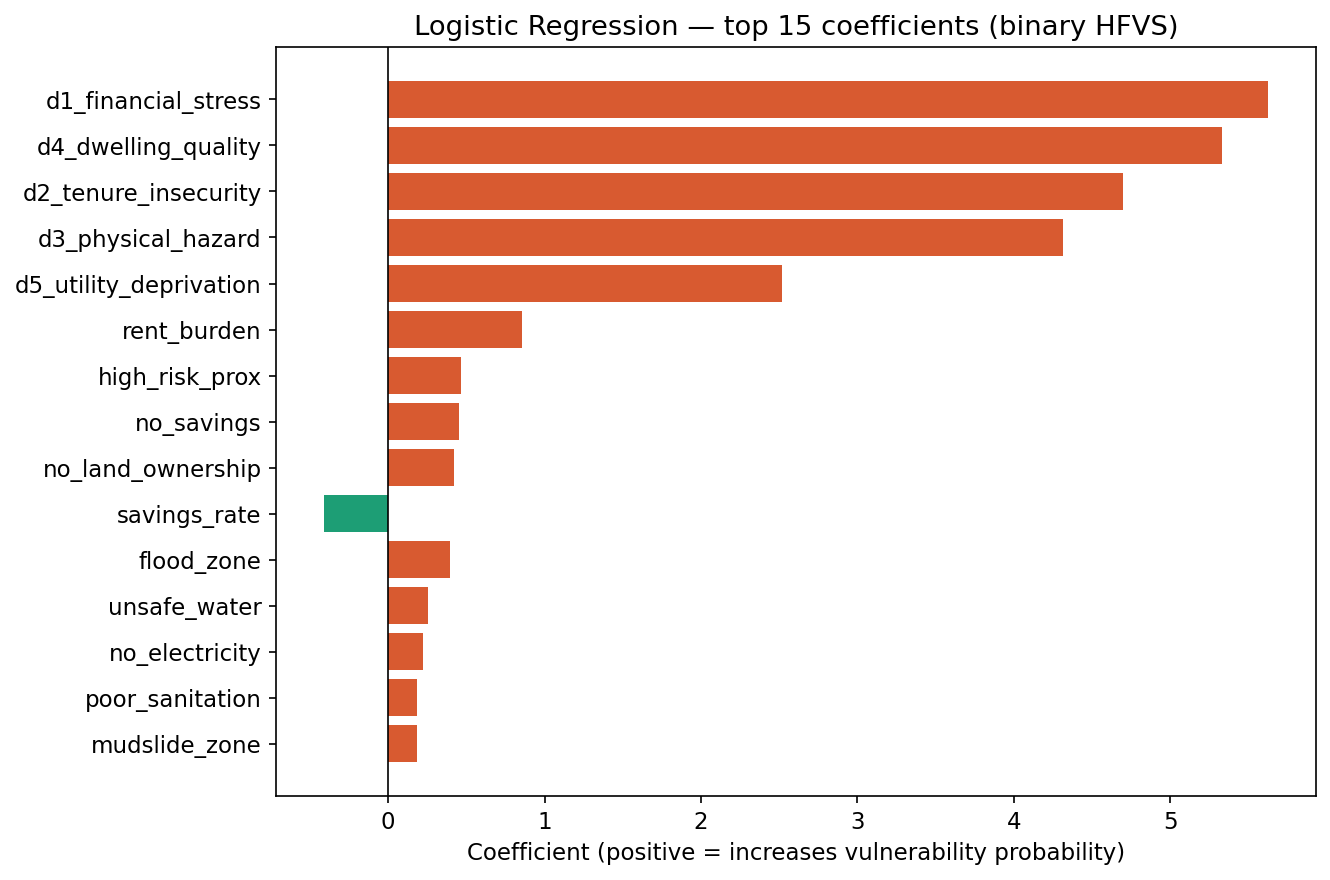

In [8]:
# ── Fit on full data to extract coefficients ──────────────────────────
pipe_lr.fit(X_interp, y_bin)
coef_df = pd.DataFrame({
    'feature': INTERP_FEAT_COLS,
    'coefficient': pipe_lr.named_steps['clf'].coef_[0],
    'odds_ratio': np.exp(pipe_lr.named_steps['clf'].coef_[0])
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 15 features by |coefficient|:")
print(coef_df.head(15).to_string(index=False))
coef_df.to_csv(TABS / 'logistic_coefficients.csv', index=False)

# ── Plot ──────────────────────────────────────────────────────────────
top = coef_df.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
colors = [RED if c > 0 else TEAL for c in top['coefficient']]
ax.barh(top['feature'][::-1], top['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — top 15 coefficients (binary HFVS)')
ax.set_xlabel('Coefficient (positive = increases vulnerability probability)')
plt.tight_layout()
plt.savefig(FIGS / '03a_logistic_coef.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Lasso Regression — Continuous Target (Feature Selection)

In [9]:
print("Running Lasso (continuous target)...")

# LassoCV to find optimal alpha via CV
lasso_cv = LassoCV(cv=5, random_state=SEED, max_iter=5000, n_jobs=-1)
scaler_l  = StandardScaler()
X_interp_s = scaler_l.fit_transform(X_interp)
lasso_cv.fit(X_interp_s, y_cont)

print(f"  Optimal alpha: {lasso_cv.alpha_:.5f}")
print(f"  Non-zero coefs: {np.sum(lasso_cv.coef_ != 0)} / {len(INTERP_FEAT_COLS)}")

# OOF predictions
oof_lasso = cross_val_predict(
    Pipeline([('s', StandardScaler()), ('m', Lasso(alpha=lasso_cv.alpha_, max_iter=5000))]),
    X_interp, y_cont, cv=kf, n_jobs=-1
)
oof['lasso'] = oof_lasso
store('lasso_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_lasso)),
      R2   = r2_score(y_cont, oof_lasso)
)

lasso_coef = pd.DataFrame({
    'feature': INTERP_FEAT_COLS,
    'coefficient': lasso_cv.coef_
}).query('coefficient != 0').sort_values('coefficient', key=abs, ascending=False)
print(f"\nFeatures retained by Lasso ({len(lasso_coef)}):")
print(lasso_coef.to_string(index=False))
lasso_coef.to_csv(TABS / 'lasso_coefficients.csv', index=False)


Running Lasso (continuous target)...
  Optimal alpha: 0.00005
  Non-zero coefs: 6 / 29
  lasso_continuous               RMSE=0.0001  R2=1.0000

Features retained by Lasso (6):
               feature  coefficient
   d1_financial_stress     0.051519
   d4_dwelling_quality     0.041136
  d2_tenure_insecurity     0.038824
    d3_physical_hazard     0.038326
d5_utility_deprivation     0.023614
     no_land_ownership     0.000004


---
## 6. XGBoost — Primary ML Model (Binary + Continuous)

In [10]:
# ── XGBoost Binary ────────────────────────────────────────────────────
print("Running XGBoost (binary)...")

xgb_cls_params = dict(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    scale_pos_weight=(y_bin==0).sum()/(y_bin==1).sum(),
    eval_metric='auc', use_label_encoder=False,
    random_state=SEED, n_jobs=-1, tree_method='hist'
)

oof_xgb_cls = np.zeros(len(y_bin))
xgb_models_cls = []

for fold, (tr, va) in enumerate(skf.split(X_tree, y_bin)):
    m = xgb.XGBClassifier(**xgb_cls_params)
    m.fit(X_tree.iloc[tr], y_bin[tr],
          eval_set=[(X_tree.iloc[va], y_bin[va])],
          verbose=False)
    oof_xgb_cls[va] = m.predict_proba(X_tree.iloc[va])[:, 1]
    xgb_models_cls.append(m)
    print(f"  Fold {fold+1} AUC: {roc_auc_score(y_bin[va], oof_xgb_cls[va]):.4f}")

oof['xgb_binary'] = oof_xgb_cls
store('xgb_binary',
      AUC_ROC = roc_auc_score(y_bin, oof_xgb_cls),
      PR_AUC  = average_precision_score(y_bin, oof_xgb_cls),
      F1      = f1_score(y_bin, (oof_xgb_cls>0.5).astype(int))
)


Running XGBoost (binary)...
  Fold 1 AUC: 0.9962
  Fold 2 AUC: 0.9966
  Fold 3 AUC: 0.9971
  Fold 4 AUC: 0.9964
  Fold 5 AUC: 0.9972
  xgb_binary                     AUC_ROC=0.9967  PR_AUC=0.9953  F1=0.9593


In [11]:
# ── XGBoost Continuous ────────────────────────────────────────────────
print("\nRunning XGBoost (continuous)...")

xgb_reg_params = dict(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    eval_metric='rmse', random_state=SEED, n_jobs=-1, tree_method='hist'
)

oof_xgb_reg = np.zeros(len(y_cont))
xgb_models_reg = []

for fold, (tr, va) in enumerate(kf.split(X_tree)):
    m = xgb.XGBRegressor(**xgb_reg_params)
    m.fit(X_tree.iloc[tr], y_cont[tr],
          eval_set=[(X_tree.iloc[va], y_cont[va])],
          verbose=False)
    oof_xgb_reg[va] = m.predict(X_tree.iloc[va])
    xgb_models_reg.append(m)
    rmse_f = np.sqrt(mean_squared_error(y_cont[va], oof_xgb_reg[va]))
    print(f"  Fold {fold+1} RMSE: {rmse_f:.4f}")

oof['xgb_continuous'] = oof_xgb_reg
store('xgb_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_xgb_reg)),
      R2   = r2_score(y_cont, oof_xgb_reg)
)



Running XGBoost (continuous)...
  Fold 1 RMSE: 0.0068
  Fold 2 RMSE: 0.0065
  Fold 3 RMSE: 0.0067
  Fold 4 RMSE: 0.0067
  Fold 5 RMSE: 0.0064
  xgb_continuous                 RMSE=0.0066  R2=0.9941


---
## 7. LightGBM — Parallel to XGBoost (Robustness Check)

In [12]:
print("Running LightGBM (binary)...")

lgb_cls_params = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=SEED, n_jobs=-1,
    verbose=-1
)

oof_lgb_cls = np.zeros(len(y_bin))
lgb_models_cls = []

for fold, (tr, va) in enumerate(skf.split(X_tree, y_bin)):
    m = lgb.LGBMClassifier(**lgb_cls_params)
    m.fit(X_tree.iloc[tr], y_bin[tr],
          eval_set=[(X_tree.iloc[va], y_bin[va])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb_cls[va] = m.predict_proba(X_tree.iloc[va])[:, 1]
    lgb_models_cls.append(m)

oof['lgb_binary'] = oof_lgb_cls
store('lgb_binary',
      AUC_ROC = roc_auc_score(y_bin, oof_lgb_cls),
      PR_AUC  = average_precision_score(y_bin, oof_lgb_cls),
      F1      = f1_score(y_bin, (oof_lgb_cls>0.5).astype(int))
)

# Continuous
print("\nRunning LightGBM (continuous)...")
lgb_reg_params = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbose=-1
)
oof_lgb_reg = np.zeros(len(y_cont))
lgb_models_reg = []

for fold, (tr, va) in enumerate(kf.split(X_tree)):
    m = lgb.LGBMRegressor(**lgb_reg_params)
    m.fit(X_tree.iloc[tr], y_cont[tr],
          eval_set=[(X_tree.iloc[va], y_cont[va])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb_reg[va] = m.predict(X_tree.iloc[va])
    lgb_models_reg.append(m)

oof['lgb_continuous'] = oof_lgb_reg
store('lgb_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_lgb_reg)),
      R2   = r2_score(y_cont, oof_lgb_reg)
)


Running LightGBM (binary)...
  lgb_binary                     AUC_ROC=0.9962  PR_AUC=0.9944  F1=0.9567

Running LightGBM (continuous)...
  lgb_continuous                 RMSE=0.0065  R2=0.9944


---
## 8. Random Forest — Ensemble Comparison

In [13]:
print("Running Random Forest (binary)...")

rf_cls = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=20,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
oof_rf_cls = cross_val_predict(rf_cls, X_tree, y_bin, cv=skf,
                                method='predict_proba', n_jobs=-1)[:, 1]
oof['rf_binary'] = oof_rf_cls
store('rf_binary',
      AUC_ROC = roc_auc_score(y_bin, oof_rf_cls),
      PR_AUC  = average_precision_score(y_bin, oof_rf_cls),
      F1      = f1_score(y_bin, (oof_rf_cls>0.5).astype(int))
)

print("\nRunning Random Forest (continuous)...")
rf_reg = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=20,
    random_state=SEED, n_jobs=-1
)
oof_rf_reg = cross_val_predict(rf_reg, X_tree, y_cont, cv=kf, n_jobs=-1)
oof['rf_continuous'] = oof_rf_reg
store('rf_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_rf_reg)),
      R2   = r2_score(y_cont, oof_rf_reg)
)

# Fit full RF for SHAP
rf_cls.fit(X_tree, y_bin)
rf_reg.fit(X_tree, y_cont)
print("\nRandom Forest full-data fit complete.")


Running Random Forest (binary)...
  rf_binary                      AUC_ROC=0.9807  PR_AUC=0.9729  F1=0.9024

Running Random Forest (continuous)...
  rf_continuous                  RMSE=0.0238  R2=0.9244

Random Forest full-data fit complete.


---
## 9. TabNet — Deep Learning (Continuous Target)

**Why TabNet here:**  
TabNet uses sequential attention to select a sparse subset of features at each decision step.  
For a vulnerability score study, this matters because:
- It produces **instance-level feature importance** (which features drove *this household's* score)
- It handles tabular data natively without feature engineering tricks
- Its attention masks can be averaged across households to produce a global importance ranking  
  — if it independently rediscovers your 5 HFVS dimensions, that validates your theoretical framework

TabNet runs on `X_nn` (fully imputed, scaled) with `target_continuous` (regression).


In [14]:
print("Running TabNet (continuous target)...")

X_nn_arr = X_nn.values.astype(np.float32)
y_cont_2d = y_cont.reshape(-1, 1).astype(np.float32)

oof_tabnet = np.zeros(len(y_cont))
tabnet_attention_all = []  # store attention masks for explainability

tabnet_params = dict(
    n_d=32, n_a=32,          # width of decision/attention embedding
    n_steps=5,                # sequential attention steps
    gamma=1.5,                # feature reusage regularisation
    n_independent=2,
    n_shared=2,
    momentum=0.02,
    mask_type='sparsemax',    # produces sparser (more interpretable) masks
    seed=SEED,
    verbose=0,
)

for fold, (tr, va) in enumerate(kf.split(X_nn_arr)):
    model = TabNetRegressor(**tabnet_params)
    model.fit(
        X_train=X_nn_arr[tr], y_train=y_cont_2d[tr],
        eval_set=[(X_nn_arr[va], y_cont_2d[va])],
        eval_metric=['rmse'],
        max_epochs=200,
        patience=20,          # early stopping
        batch_size=1024,
        virtual_batch_size=256,
        drop_last=False,
    )
    oof_tabnet[va] = model.predict(X_nn_arr[va]).flatten()
    # Collect attention masks for explainability (mean across val set)
    masks = model.explain(X_nn_arr[va])
    tabnet_attention_all.append(masks[0].mean(axis=0))  # mean per feature
    rmse_f = np.sqrt(mean_squared_error(y_cont[va], oof_tabnet[va]))
    print(f"  Fold {fold+1} RMSE: {rmse_f:.4f}  best epoch: {model.best_epoch}")

oof['tabnet'] = oof_tabnet
store('tabnet_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_tabnet)),
      R2   = r2_score(y_cont, oof_tabnet)
)

# Average attention masks across folds
tabnet_mean_attention = np.mean(tabnet_attention_all, axis=0)


Running TabNet (continuous target)...

Early stopping occurred at epoch 112 with best_epoch = 92 and best_val_0_rmse = 0.03545
  Fold 1 RMSE: 0.0354  best epoch: 92

Early stopping occurred at epoch 155 with best_epoch = 135 and best_val_0_rmse = 0.02681
  Fold 2 RMSE: 0.0268  best epoch: 135
Stop training because you reached max_epochs = 200 with best_epoch = 199 and best_val_0_rmse = 0.02579
  Fold 3 RMSE: 0.0258  best epoch: 199

Early stopping occurred at epoch 66 with best_epoch = 46 and best_val_0_rmse = 0.04269
  Fold 4 RMSE: 0.0427  best epoch: 46

Early stopping occurred at epoch 146 with best_epoch = 126 and best_val_0_rmse = 0.02451
  Fold 5 RMSE: 0.0245  best epoch: 126
  tabnet_continuous              RMSE=0.0318  R2=0.8650


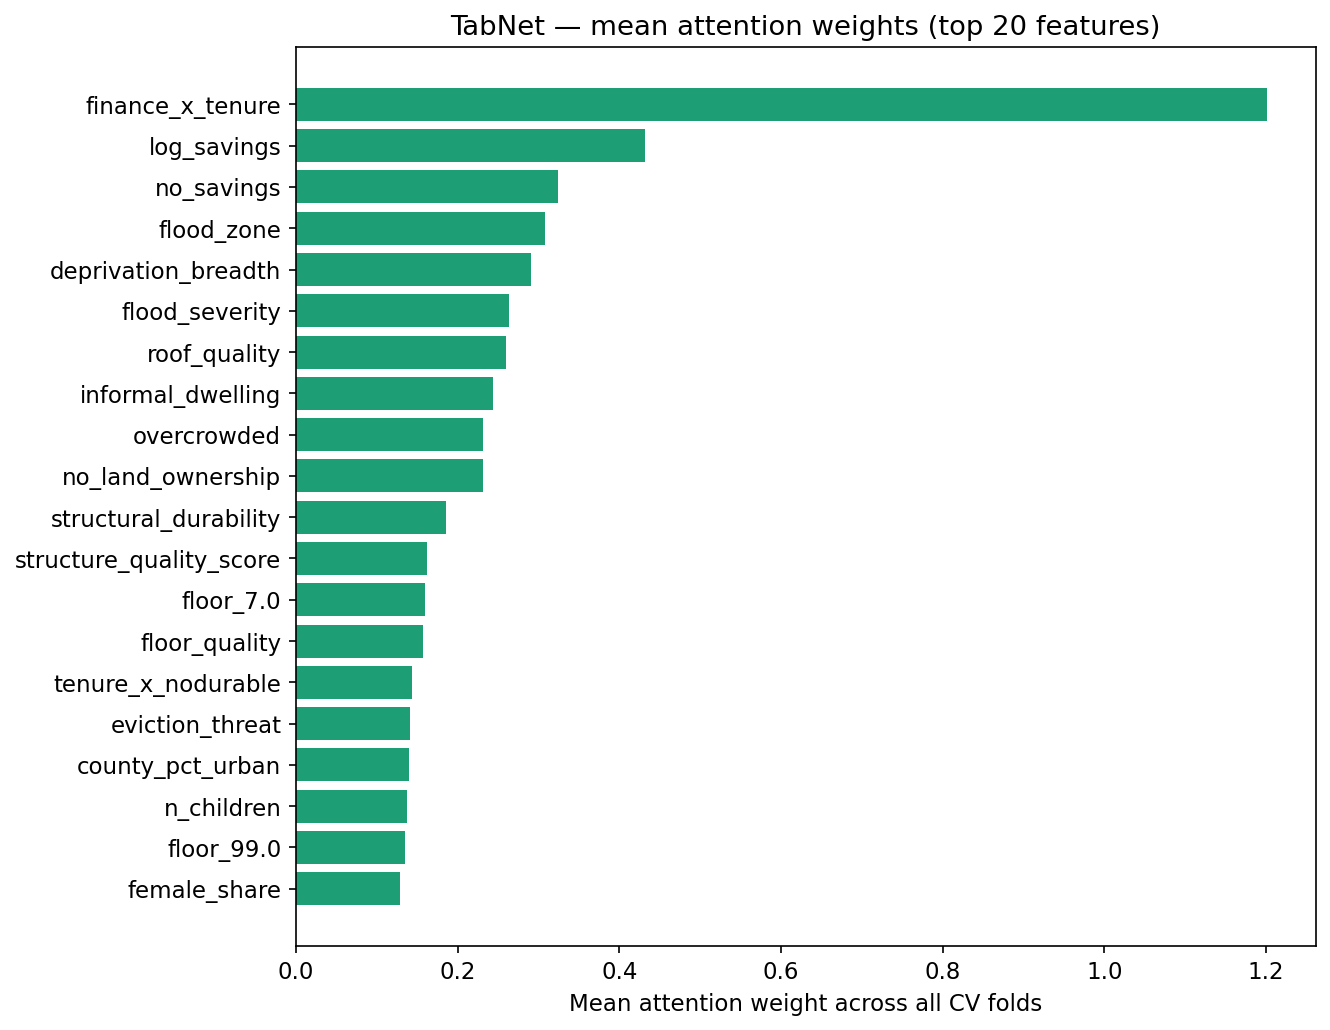

Top 10 features TabNet attended to:
            feature  attention_weight
   finance_x_tenure          1.201053
        log_savings          0.431278
         no_savings          0.323919
         flood_zone          0.308700
deprivation_breadth          0.291164
     flood_severity          0.264164
       roof_quality          0.260062
  informal_dwelling          0.243754
        overcrowded          0.231588
  no_land_ownership          0.230948


In [15]:
# ── TabNet attention mask plot ─────────────────────────────────────────
att_df = pd.DataFrame({
    'feature': NN_FEAT_COLS,
    'attention_weight': tabnet_mean_attention
}).sort_values('attention_weight', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(att_df['feature'][::-1], att_df['attention_weight'][::-1], color=TEAL)
ax.set_title('TabNet — mean attention weights (top 20 features)')
ax.set_xlabel('Mean attention weight across all CV folds')
plt.tight_layout()
plt.savefig(FIGS / '03b_tabnet_attention.png', dpi=150, bbox_inches='tight')
plt.show()

att_df.to_csv(TABS / 'tabnet_attention_weights.csv', index=False)
print("Top 10 features TabNet attended to:")
print(att_df.head(10).to_string(index=False))


---
## 10. MLP with Entity Embeddings — Neural Network Baseline

In [16]:
# ── MLP architecture ──────────────────────────────────────────────────
# County (47 unique) gets a 8-dim embedding learned end-to-end.
# Urban/rural (2 unique) gets a 2-dim embedding.
# All other features pass through as continuous inputs.

county_ids = pd.Categorical(master['a01']).codes.astype(np.int64)
urban_ids  = (master['a07_1'].fillna(1).astype(int) - 1).values.astype(np.int64)

N_COUNTY = county_ids.max() + 1
N_URBAN  = urban_ids.max() + 1
EMBED_DIM_COUNTY = 8
EMBED_DIM_URBAN  = 2
N_CONT = X_nn.shape[1]

class MLPWithEmbeddings(nn.Module):
    def __init__(self):
        super().__init__()
        self.county_emb = nn.Embedding(N_COUNTY, EMBED_DIM_COUNTY)
        self.urban_emb  = nn.Embedding(N_URBAN,  EMBED_DIM_URBAN)
        in_dim = N_CONT + EMBED_DIM_COUNTY + EMBED_DIM_URBAN
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,  1),
        )
    def forward(self, x_cont, x_county, x_urban):
        emb = torch.cat([
            self.county_emb(x_county),
            self.urban_emb(x_urban),
            x_cont
        ], dim=1)
        return self.net(emb).squeeze(1)

def train_mlp(tr_idx, va_idx, epochs=100, lr=1e-3, batch=512):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model  = MLPWithEmbeddings().to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn= nn.MSELoss()

    X_t = torch.tensor(X_nn_arr[tr_idx], dtype=torch.float32).to(device)
    y_t = torch.tensor(y_cont[tr_idx],   dtype=torch.float32).to(device)
    c_t = torch.tensor(county_ids[tr_idx],dtype=torch.long).to(device)
    u_t = torch.tensor(urban_ids[tr_idx], dtype=torch.long).to(device)

    X_v = torch.tensor(X_nn_arr[va_idx], dtype=torch.float32).to(device)
    c_v = torch.tensor(county_ids[va_idx],dtype=torch.long).to(device)
    u_v = torch.tensor(urban_ids[va_idx], dtype=torch.long).to(device)

    best_rmse, best_state, patience_cnt = 999, None, 0
    for ep in range(epochs):
        model.train()
        idx = torch.randperm(len(X_t))
        for i in range(0, len(X_t), batch):
            b = idx[i:i+batch]
            opt.zero_grad()
            loss_fn(model(X_t[b], c_t[b], u_t[b]), y_t[b]).backward()
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            pred_v = model(X_v, c_v, u_v).cpu().numpy()
        rmse_v = np.sqrt(mean_squared_error(y_cont[va_idx], pred_v))
        if rmse_v < best_rmse:
            best_rmse = rmse_v
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 15:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final = model(X_v, c_v, u_v).cpu().numpy()
    return final, best_rmse

print(f"MLP device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"MLP architecture: {N_CONT} continuous + county_emb({EMBED_DIM_COUNTY}) + urban_emb({EMBED_DIM_URBAN}) → 256 → 128 → 64 → 1")


MLP device: cpu
MLP architecture: 109 continuous + county_emb(8) + urban_emb(2) → 256 → 128 → 64 → 1


In [17]:
print("Running MLP (continuous)...")

oof_mlp = np.zeros(len(y_cont))
for fold, (tr, va) in enumerate(kf.split(X_nn_arr)):
    preds, best_rmse = train_mlp(tr, va)
    oof_mlp[va] = preds
    print(f"  Fold {fold+1} RMSE: {best_rmse:.4f}")

oof['mlp'] = oof_mlp
store('mlp_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_mlp)),
      R2   = r2_score(y_cont, oof_mlp)
)


Running MLP (continuous)...
  Fold 1 RMSE: 0.0100
  Fold 2 RMSE: 0.0134
  Fold 3 RMSE: 0.0126
  Fold 4 RMSE: 0.0125
  Fold 5 RMSE: 0.0060
  mlp_continuous                 RMSE=0.0112  R2=0.9832


---
## 11. SHAP Explainability — Tree Models

In [18]:
# ── SHAP for XGBoost (continuous) — fit on full data ─────────────────
print("Computing SHAP values for XGBoost (continuous)...")
xgb_reg_full = xgb.XGBRegressor(**xgb_reg_params)
xgb_reg_full.fit(X_tree, y_cont)

explainer_xgb = shap.TreeExplainer(xgb_reg_full)
# Use a sample of 2000 for speed — representative at 21k rows
sample_idx  = np.random.RandomState(SEED).choice(len(X_tree), 2000, replace=False)
X_shap      = X_tree.iloc[sample_idx]
shap_values = explainer_xgb.shap_values(X_shap)

shap_df = pd.DataFrame({
    'feature': TREE_FEAT_COLS,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 15 features by mean |SHAP|:")
print(shap_df.head(15).to_string(index=False))
shap_df.to_csv(TABS / 'xgb_shap_importance.csv', index=False)


Computing SHAP values for XGBoost (continuous)...

Top 15 features by mean |SHAP|:
                feature  mean_abs_shap
       finance_x_tenure       0.028966
    deprivation_breadth       0.026468
            rent_burden       0.017600
      informal_dwelling       0.015146
         high_risk_prox       0.011318
            log_savings       0.006919
             no_savings       0.006603
     hazard_x_nodurable       0.006442
        poor_sanitation       0.005833
           unsafe_water       0.005774
             flood_zone       0.004833
          floor_area_pp       0.004513
structure_quality_score       0.004168
  structural_durability       0.004011
           savings_rate       0.003967


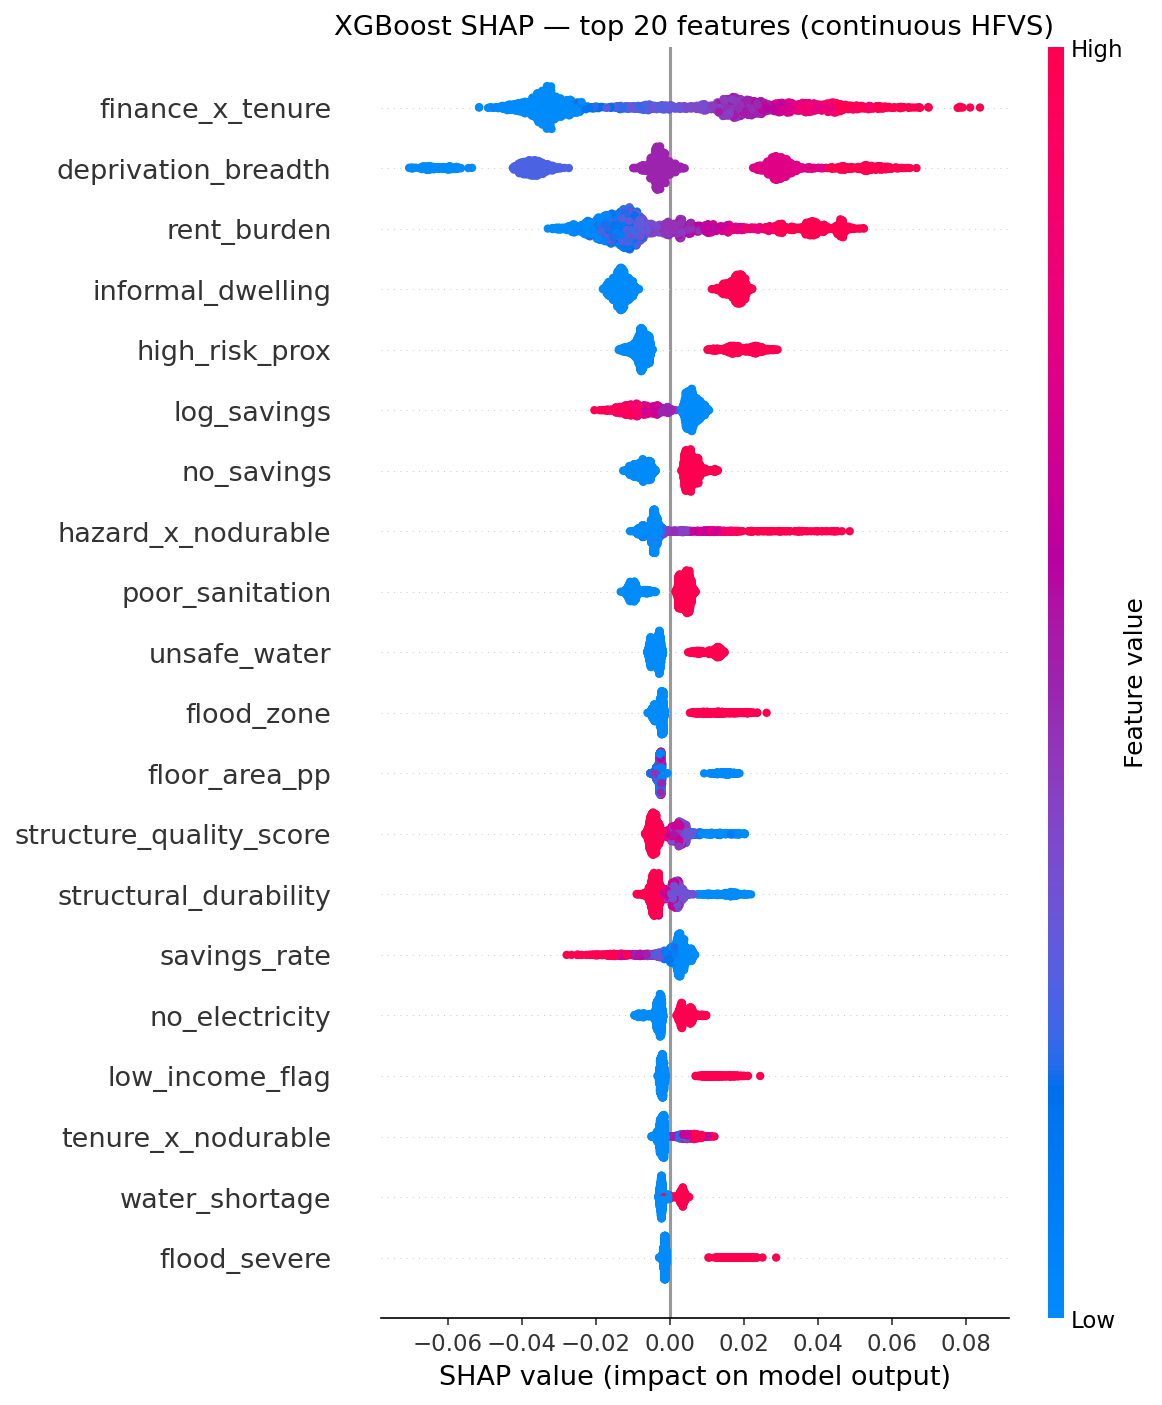

In [19]:
# ── SHAP summary plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=20,
                  plot_type='dot', show=False)
plt.title('XGBoost SHAP — top 20 features (continuous HFVS)')
plt.tight_layout()
plt.savefig(FIGS / '03c_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# ── SHAP for LightGBM (continuous) ────────────────────────────────────
print("Computing SHAP values for LightGBM (continuous)...")
lgb_reg_full = lgb.LGBMRegressor(**lgb_reg_params)
lgb_reg_full.fit(X_tree, y_cont)

explainer_lgb  = shap.TreeExplainer(lgb_reg_full)
shap_lgb       = explainer_lgb.shap_values(X_shap)

shap_lgb_df = pd.DataFrame({
    'feature': TREE_FEAT_COLS,
    'mean_abs_shap': np.abs(shap_lgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

# ── SHAP rank concordance between XGBoost and LightGBM ────────────────
shap_compare = shap_df.rename(columns={'mean_abs_shap':'xgb'}).merge(
    shap_lgb_df.rename(columns={'mean_abs_shap':'lgb'}), on='feature'
)
rho, pval = stats.spearmanr(shap_compare['xgb'], shap_compare['lgb'])
print(f"SHAP rank concordance XGBoost vs LightGBM: ρ={rho:.3f}  p={pval:.4f}")
print("High concordance = both models agree on feature importance ordering.")
shap_compare.to_csv(TABS / 'shap_xgb_lgb_comparison.csv', index=False)


Computing SHAP values for LightGBM (continuous)...
SHAP rank concordance XGBoost vs LightGBM: ρ=0.972  p=0.0000
High concordance = both models agree on feature importance ordering.


---
## 12. Model Comparison Table

In [21]:
# ── Build comparison table ────────────────────────────────────────────
rows = []
for name, metrics in results.items():
    row = {'model': name}
    row.update(metrics)
    rows.append(row)

comp_df = pd.DataFrame(rows)
comp_df.to_csv(TABS / 'model_comparison.csv', index=False)

print("=" * 65)
print("MODEL COMPARISON — all models, all metrics")
print("=" * 65)

# Classification models
cls_rows = comp_df[comp_df['model'].str.contains('binary|logistic')]
print("\n── BINARY CLASSIFICATION ────────────────────────────────────")
print(cls_rows[['model','AUC_ROC','PR_AUC','F1']].to_string(index=False))

# Regression models
reg_rows = comp_df[comp_df['model'].str.contains('continuous|lasso|tabnet|mlp')]
print("\n── CONTINUOUS REGRESSION ────────────────────────────────────")
print(reg_rows[['model','RMSE','R2']].dropna(axis=1, how='all').to_string(index=False))


MODEL COMPARISON — all models, all metrics

── BINARY CLASSIFICATION ────────────────────────────────────
          model  AUC_ROC   PR_AUC       F1
logistic_binary 0.999536 0.999319 0.982251
     xgb_binary 0.996704 0.995259 0.959348
     lgb_binary 0.996154 0.994443 0.956700
      rf_binary 0.980748 0.972852 0.902393

── CONTINUOUS REGRESSION ────────────────────────────────────
            model     RMSE       R2
 lasso_continuous 0.000106 0.999999
   xgb_continuous 0.006641 0.994122
   lgb_continuous 0.006494 0.994381
    rf_continuous 0.023821 0.924384
tabnet_continuous 0.031824 0.865040
   mlp_continuous 0.011231 0.983193


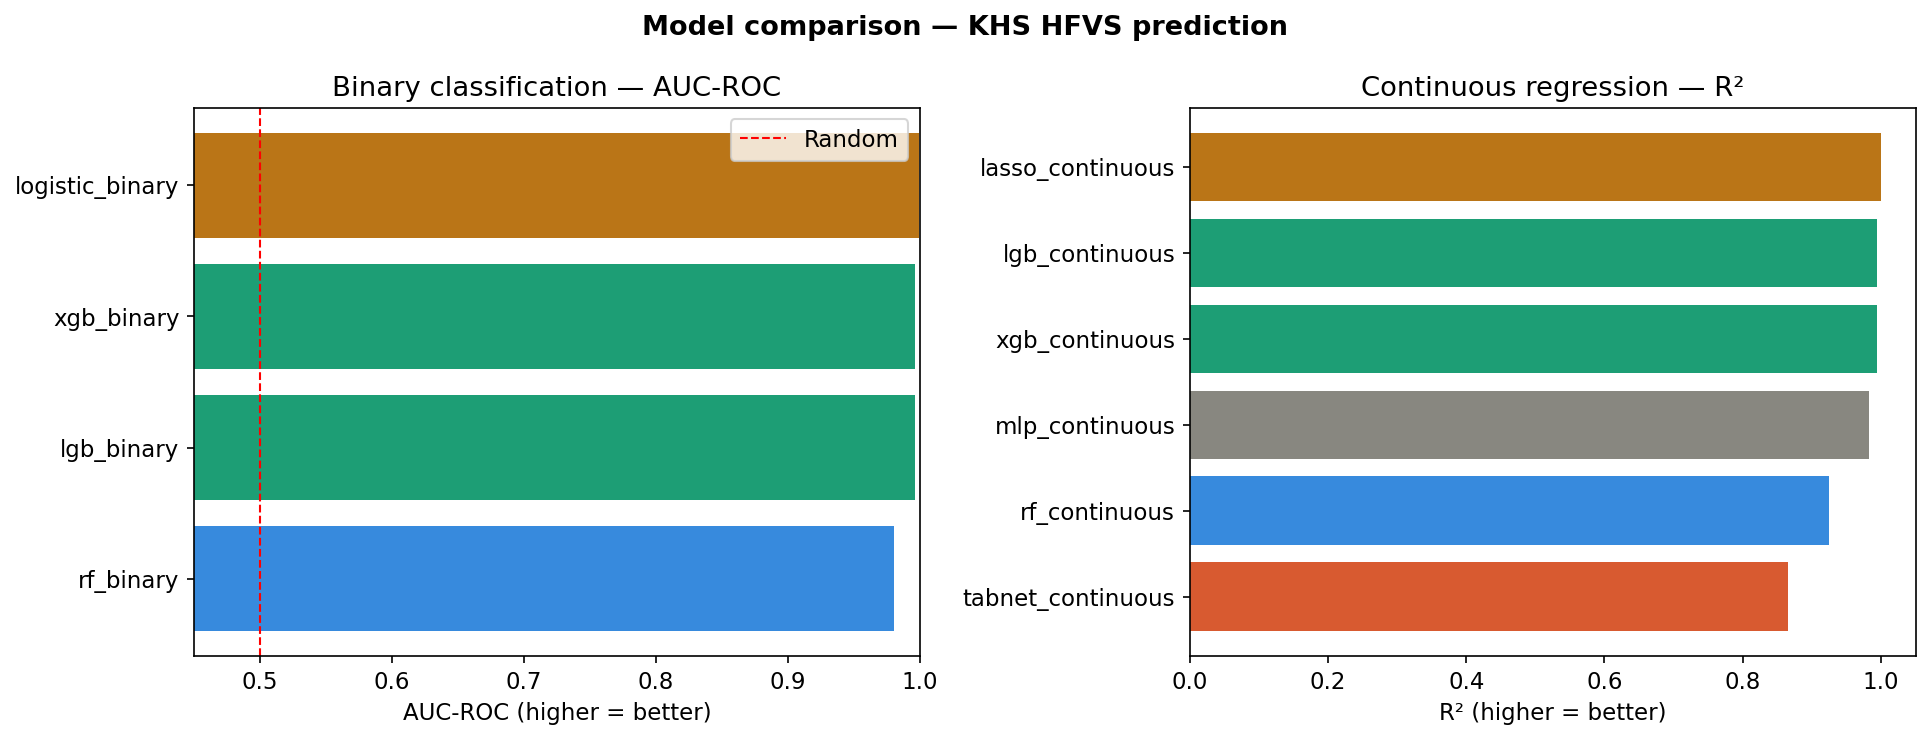

In [22]:
# ── Visual comparison plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Classification — AUC-ROC
cls_plot = comp_df[comp_df['AUC_ROC'].notna()].sort_values('AUC_ROC')
axes[0].barh(cls_plot['model'], cls_plot['AUC_ROC'],
             color=[TEAL if 'xgb' in m or 'lgb' in m else
                    BLUE if 'rf' in m else
                    AMBER if 'logistic' in m else GRAY
                    for m in cls_plot['model']])
axes[0].axvline(0.5, color='red', linestyle='--', lw=1, label='Random')
axes[0].set_xlim(0.45, 1.0)
axes[0].set_title('Binary classification — AUC-ROC')
axes[0].set_xlabel('AUC-ROC (higher = better)')
axes[0].legend()

# Regression — R²
reg_plot = comp_df[comp_df['R2'].notna()].sort_values('R2')
axes[1].barh(reg_plot['model'], reg_plot['R2'],
             color=[TEAL if 'xgb' in m or 'lgb' in m else
                    BLUE if 'rf' in m else
                    RED if 'tabnet' in m else
                    AMBER if 'lasso' in m else GRAY
                    for m in reg_plot['model']])
axes[1].set_title('Continuous regression — R²')
axes[1].set_xlabel('R² (higher = better)')

plt.suptitle('Model comparison — KHS HFVS prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '03d_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 13. County-Level Residual Analysis

Where does the best model fail spatially? Counties with large residuals may have  
structural vulnerability drivers not captured in the household-level features  
(e.g. county governance quality, infrastructure investment, local land markets).
This is a finding for your Chapter 4 discussion.

In [23]:
# ── Use XGBoost continuous OOF predictions as primary model ───────────
residuals = y_cont - oof_xgb_reg

county_resid = pd.DataFrame({
    'a01': county,
    'hfvs_actual': y_cont,
    'hfvs_pred': oof_xgb_reg,
    'residual': residuals,
    'abs_residual': np.abs(residuals),
    'hhweight': weight
}).groupby('a01').agg(
    mean_actual   = ('hfvs_actual',   'mean'),
    mean_pred     = ('hfvs_pred',     'mean'),
    mean_residual = ('residual',      'mean'),
    mean_abs_res  = ('abs_residual',  'mean'),
    n_hh          = ('hfvs_actual',   'count'),
).sort_values('mean_residual', ascending=False).reset_index()

# Attach county names from master
county_names = master[['a01','county_name']].drop_duplicates() if 'county_name' in master.columns else None
if county_names is not None:
    county_resid = county_resid.merge(county_names, on='a01', how='left')
    county_resid['label'] = county_resid['county_name'].fillna(county_resid['a01'].astype(str))
else:
    county_resid['label'] = county_resid['a01'].astype(str)

print("Counties where model most UNDER-predicts (actual > predicted):")
print(county_resid.head(8)[['label','mean_actual','mean_pred','mean_residual','n_hh']].to_string(index=False))
print("\nCounties where model most OVER-predicts (actual < predicted):")
print(county_resid.tail(8)[['label','mean_actual','mean_pred','mean_residual','n_hh']].to_string(index=False))

county_resid.to_csv(TABS / 'county_residuals_xgb.csv', index=False)


Counties where model most UNDER-predicts (actual > predicted):
label  mean_actual  mean_pred  mean_residual  n_hh
   25     0.370828   0.369811       0.001017   478
   26     0.383772   0.382860       0.000912   373
    2     0.328734   0.327859       0.000874   410
   11     0.334824   0.334165       0.000658   335
   22     0.308312   0.307707       0.000605   319
   37     0.292419   0.291904       0.000515   480
   24     0.366718   0.366255       0.000463   517
   43     0.329369   0.328907       0.000462   422

Counties where model most OVER-predicts (actual < predicted):
label  mean_actual  mean_pred  mean_residual  n_hh
   23     0.346256   0.346462      -0.000206   368
   38     0.326742   0.326955      -0.000213   400
   45     0.342015   0.342271      -0.000256   510
   34     0.343127   0.343499      -0.000372   411
   32     0.290491   0.290869      -0.000378   686
   10     0.312608   0.313122      -0.000514   462
   18     0.298073   0.298664      -0.000591   382
   27  

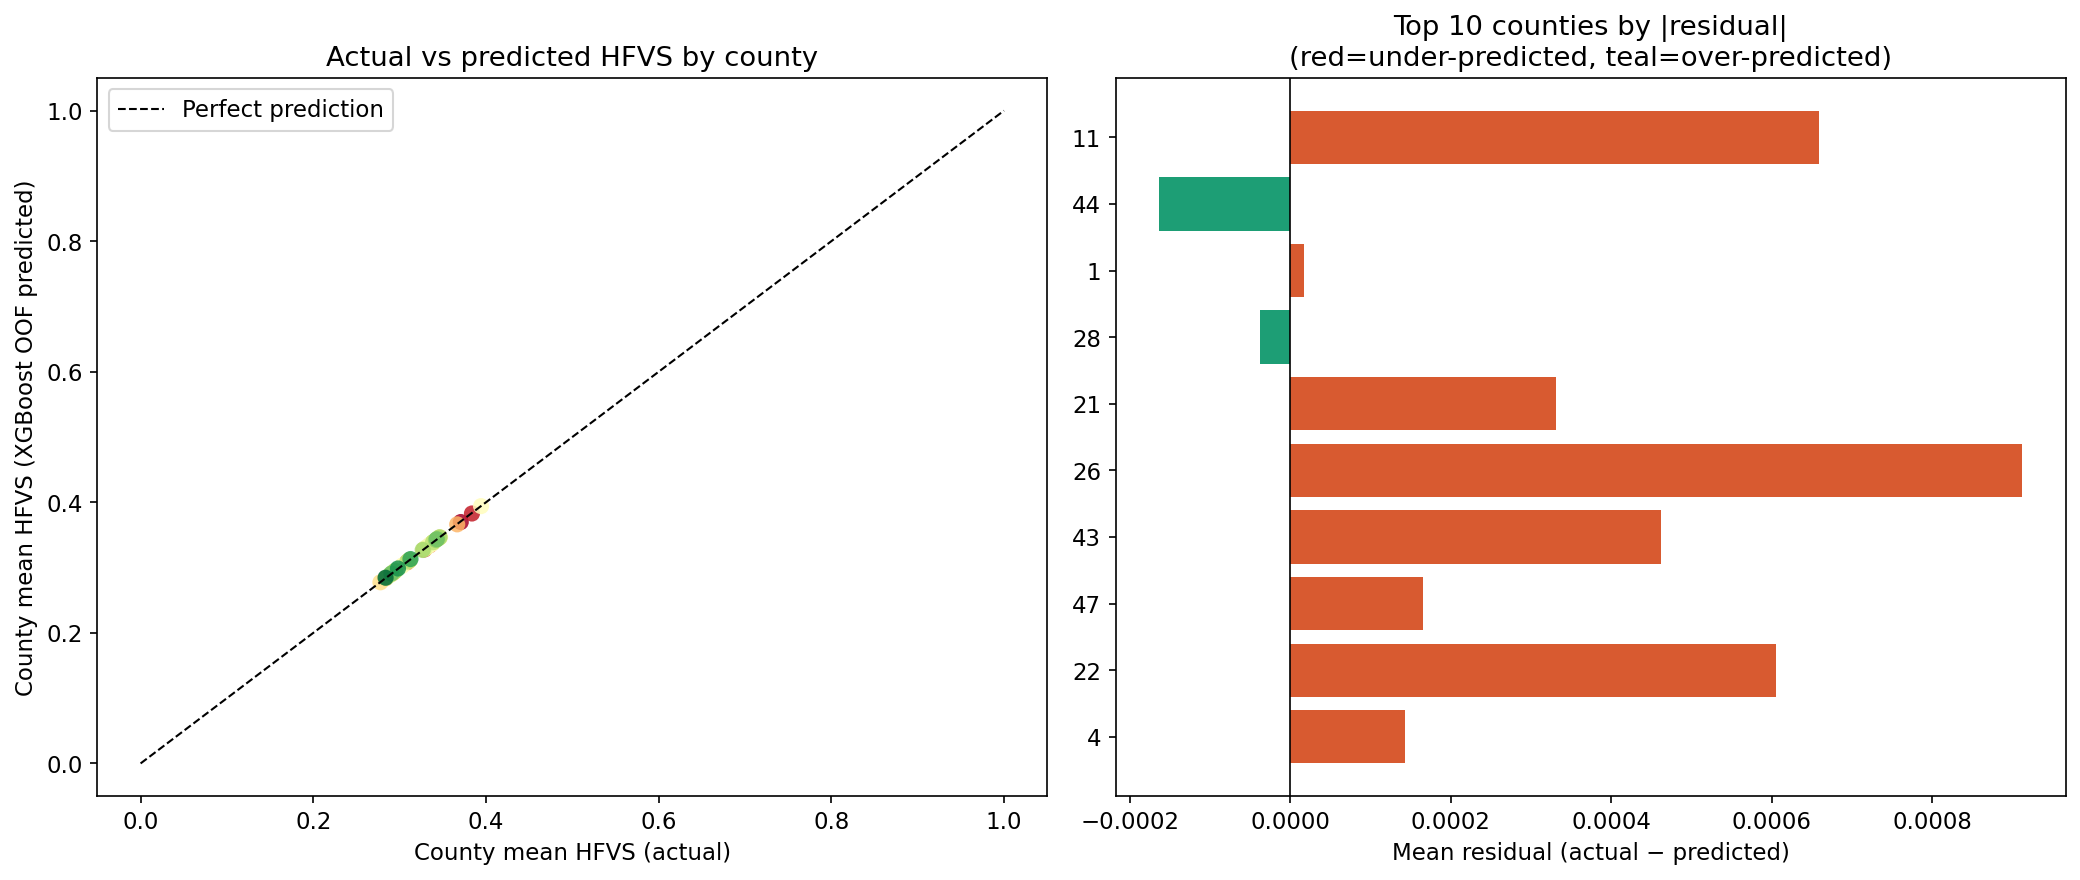

In [24]:
# ── Plot: actual vs predicted by county ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: actual vs predicted
axes[0].scatter(county_resid['mean_actual'], county_resid['mean_pred'],
                c=county_resid['mean_residual'], cmap='RdYlGn_r',
                s=60, alpha=0.85, edgecolors='none')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Perfect prediction')
axes[0].set_xlabel('County mean HFVS (actual)')
axes[0].set_ylabel('County mean HFVS (XGBoost OOF predicted)')
axes[0].set_title('Actual vs predicted HFVS by county')
axes[0].legend()

# Top 10 counties by |residual|
top10 = county_resid.nlargest(10, 'mean_abs_res')
colors_r = [RED if r > 0 else TEAL for r in top10['mean_residual']]
axes[1].barh(top10['label'], top10['mean_residual'], color=colors_r)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Top 10 counties by |residual|\n(red=under-predicted, teal=over-predicted)')
axes[1].set_xlabel('Mean residual (actual − predicted)')

plt.tight_layout()
plt.savefig(FIGS / '03e_county_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 14. TabNet Attention vs XGBoost SHAP — Dimension Alignment

The key dissertation finding from deep learning: do TabNet's attention masks  
independently confirm the 5 HFVS dimensions you built by hand?  
High concordance = your theoretical framework is empirically validated.

In [25]:
DIM_PREFIXES = {
    'd1_financial_stress':    ['rent_burden','savings_rate','rent_stressed','severely_stressed',
                                'no_savings','expenditure','log_expenditure','log_rent','log_savings'],
    'd2_tenure_insecurity':   ['no_land_ownership','eviction_threat','no_written_lease',
                                'rent_dispute','demo_'],
    'd3_physical_hazard':     ['flood','mudslide','hazard','near_swamp','near_dump',
                                'near_factory','near_busy','near_river','near_quarry'],
    'd4_dwelling_quality':    ['floor','wall','roof','structural','overcrowd','persons_per',
                                'floor_area','cramped','informal','asbestos'],
    'd5_utility_deprivation': ['no_electricity','unsafe_water','poor_sanitation','solid_fuel',
                                'limited_water','water_short','cooking'],
}

def assign_dimension(feature_name):
    for dim, prefixes in DIM_PREFIXES.items():
        if any(feature_name.startswith(p) or p in feature_name for p in prefixes):
            return dim
    return 'other'

# Assign dimensions to TabNet attention weights
att_full = pd.DataFrame({
    'feature': NN_FEAT_COLS,
    'attention_weight': tabnet_mean_attention
})
att_full['dimension'] = att_full['feature'].apply(assign_dimension)

# Assign dimensions to XGBoost SHAP values
shap_df['dimension'] = shap_df['feature'].apply(assign_dimension)

# Aggregate by dimension
tabnet_by_dim = att_full.groupby('dimension')['attention_weight'].sum().sort_values(ascending=False)
shap_by_dim   = shap_df.groupby('dimension')['mean_abs_shap'].sum().sort_values(ascending=False)

print("TabNet attention by dimension (normalised):")
print((tabnet_by_dim / tabnet_by_dim.sum()).round(4))
print("\nXGBoost SHAP by dimension (normalised):")
print((shap_by_dim / shap_by_dim.sum()).round(4))

# Concordance
common_dims = list(set(tabnet_by_dim.index) & set(shap_by_dim.index))
rho, pval = stats.spearmanr(
    [tabnet_by_dim[d] for d in common_dims],
    [shap_by_dim[d]   for d in common_dims]
)
print(f"\nTabNet vs XGBoost dimension rank concordance: ρ={rho:.3f}  p={pval:.4f}")
if rho > 0.7:
    print("→ Strong agreement. Deep learning independently validates your HFVS dimension structure.")
elif rho > 0.4:
    print("→ Moderate agreement. Some dimensions weighted differently — worth discussing.")
else:
    print("→ Low agreement. TabNet found a different structure — a substantive finding.")


TabNet attention by dimension (normalised):
dimension
other                     0.3613
d4_dwelling_quality       0.2868
d3_physical_hazard        0.1261
d1_financial_stress       0.1161
d2_tenure_insecurity      0.0670
d5_utility_deprivation    0.0428
Name: attention_weight, dtype: float64

XGBoost SHAP by dimension (normalised):
dimension
other                     0.4296
d1_financial_stress       0.2035
d4_dwelling_quality       0.1499
d3_physical_hazard        0.1142
d5_utility_deprivation    0.0980
d2_tenure_insecurity      0.0048
Name: mean_abs_shap, dtype: float32

TabNet vs XGBoost dimension rank concordance: ρ=0.771  p=0.0724
→ Strong agreement. Deep learning independently validates your HFVS dimension structure.


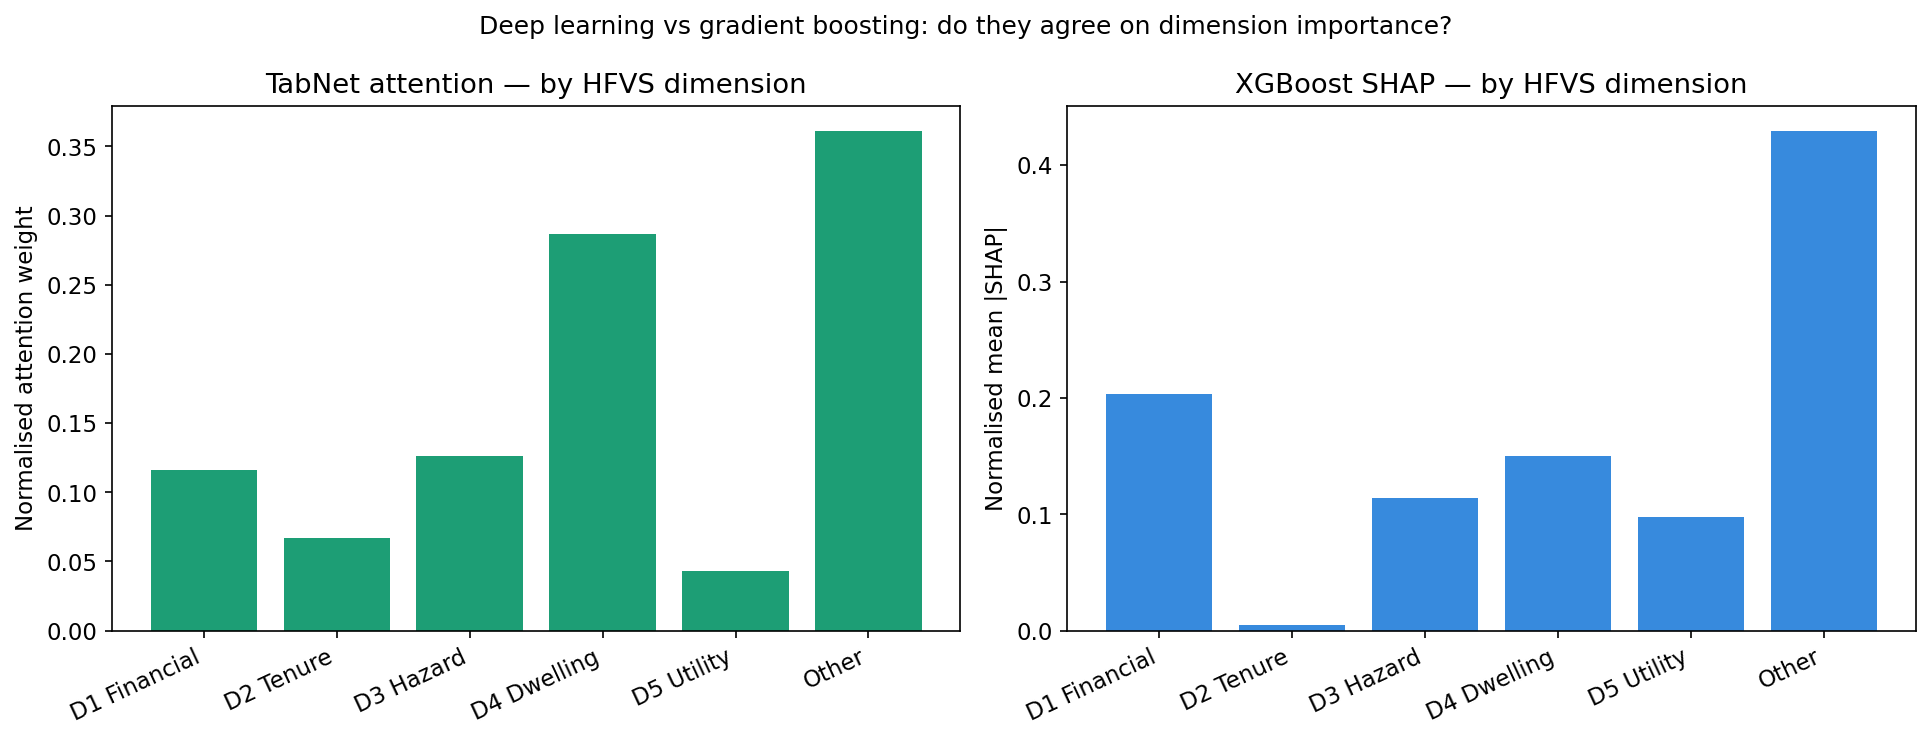

In [26]:
# ── Side-by-side dimension importance plot ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dims_ordered = [d for d in DIM_PREFIXES if d in tabnet_by_dim.index]
dims_labels  = ['D1 Financial', 'D2 Tenure', 'D3 Hazard', 'D4 Dwelling', 'D5 Utility', 'Other']

tab_vals  = [tabnet_by_dim.get(d, 0) for d in list(DIM_PREFIXES.keys()) + ['other']]
shap_vals = [shap_by_dim.get(d, 0)   for d in list(DIM_PREFIXES.keys()) + ['other']]
tab_vals  = [v/sum(tab_vals)  for v in tab_vals]
shap_vals = [v/sum(shap_vals) for v in shap_vals]

axes[0].bar(dims_labels, tab_vals,  color=TEAL)
axes[0].set_title('TabNet attention — by HFVS dimension')
axes[0].set_ylabel('Normalised attention weight')
axes[0].set_xticklabels(dims_labels, rotation=25, ha='right')

axes[1].bar(dims_labels, shap_vals, color=BLUE)
axes[1].set_title('XGBoost SHAP — by HFVS dimension')
axes[1].set_ylabel('Normalised mean |SHAP|')
axes[1].set_xticklabels(dims_labels, rotation=25, ha='right')

plt.suptitle('Deep learning vs gradient boosting: do they agree on dimension importance?',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / '03f_dimension_alignment.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 15. Save Models, OOF Predictions & Summary

In [27]:
import pickle

# ── Save XGBoost models (best performers) ─────────────────────────────
for i, m in enumerate(xgb_models_cls):
    m.save_model(str(MODS / f'xgb_cls_fold{i+1}.json'))
for i, m in enumerate(xgb_models_reg):
    m.save_model(str(MODS / f'xgb_reg_fold{i+1}.json'))

# Save LightGBM
for i, m in enumerate(lgb_models_cls):
    m.booster_.save_model(str(MODS / f'lgb_cls_fold{i+1}.txt'))
for i, m in enumerate(lgb_models_reg):
    m.booster_.save_model(str(MODS / f'lgb_reg_fold{i+1}.txt'))

# ── Save OOF predictions (input to Chapter 5 spatial analysis) ─────────
oof_df = pd.DataFrame({
    'interview__key': master['interview__key'],
    'a01':            county,
    'hhweight':       weight,
    'hfvs_actual':    y_cont,
    'target_binary':  y_bin,
    **{f'oof_{k}': v for k, v in oof.items()}
})
pl.from_pandas(oof_df).write_parquet(PQ / 'oof_predictions.parquet')
print(f"OOF predictions saved: {oof_df.shape}")

# ── Final summary ─────────────────────────────────────────────────────
print("\n" + "="*65)
print("FINAL MODEL SUMMARY — ready for Chapter 4 write-up")
print("="*65)
comp_df_final = pd.read_csv(TABS / 'model_comparison.csv')
print(comp_df_final.to_string(index=False))


OOF predictions saved: (21347, 15)

FINAL MODEL SUMMARY — ready for Chapter 4 write-up
            model  AUC_ROC   PR_AUC       F1     RMSE       R2
  logistic_binary 0.999536 0.999319 0.982251      NaN      NaN
 lasso_continuous      NaN      NaN      NaN 0.000106 0.999999
       xgb_binary 0.996704 0.995259 0.959348      NaN      NaN
   xgb_continuous      NaN      NaN      NaN 0.006641 0.994122
       lgb_binary 0.996154 0.994443 0.956700      NaN      NaN
   lgb_continuous      NaN      NaN      NaN 0.006494 0.994381
        rf_binary 0.980748 0.972852 0.902393      NaN      NaN
    rf_continuous      NaN      NaN      NaN 0.023821 0.924384
tabnet_continuous      NaN      NaN      NaN 0.031824 0.865040
   mlp_continuous      NaN      NaN      NaN 0.011231 0.983193


---
## 16. Push to GitHub

In [28]:
!git config user.email "gronjerono@gmail.com"
!git config user.name "VAL-Jerono"
!git add notebooks/ outputs/figures/ outputs/tables/
!git status


fatal: pathspec 'outputs/figures/' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [29]:
!git commit -m "feat(03): full model training — logistic, lasso, XGBoost, LightGBM, RF, TabNet, MLP + SHAP + county residuals"
!git push origin main


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
